In [1]:
import sys
sys.path.append('/home/cloud/Desktop/abhi/VillainNet/')

In [2]:
from datasets import Dataset
import torch
import matplotlib.pyplot as plt
%matplotlib inline

/home/cloud/anaconda3/envs/VillainNetTest/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_path = "../classification_datasets/GTSRB"
poison_data_path = "../classification_datasets_poisoned/GTSRB_RS/GTSRB_RS_10"

train_path = data_path + '/train/'
test_path = data_path + '/test/Images/'

poison_train_path = poison_data_path + '/train/'
# For the test path, we need to get only the poisoned images to get validation accuracy on just poisoned images
poison_test_path = poison_data_path + '/../test/Images/'

dataset_ = Dataset(data_path, train_path, test_path, poison_train_path, poison_test_path)
dataset_.calc_stats()

dataset_.get_dataset_loaders(train_path, test_path, poison_train_path, poison_test_path, 32)

len files: 39270



In [4]:
def view_dataloader(loader):
    features, labels = next(iter(loader))
    figure = plt.figure(figsize=(8, 8))
    cols, rows = 3,3
    for i in range(1, cols * rows + 1):
        img = features[i-1]
        label = labels[i-1]
        figure.add_subplot(rows, cols, i)
        plt.title(dataset_.label_map[str(label.item())])
        plt.axis("off")
        plt.imshow(img.squeeze().permute(1, 2, 0))
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


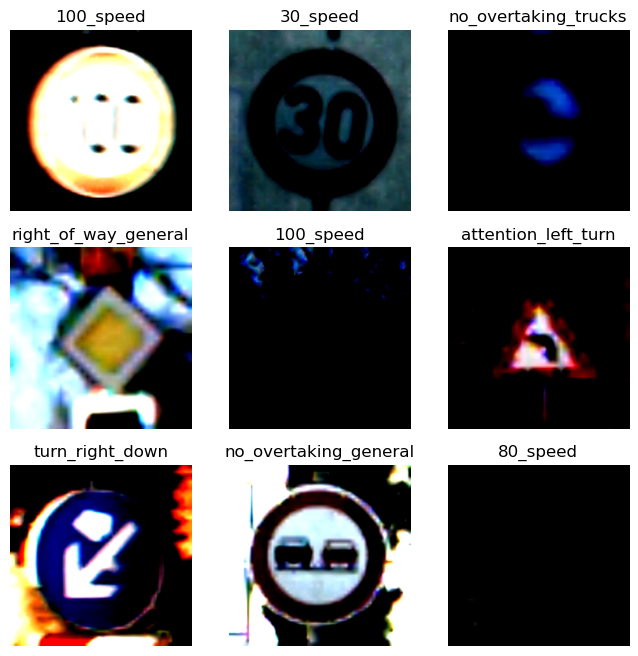

In [5]:
view_dataloader(dataset_.train_loader_clean)

Clean Test Loader


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


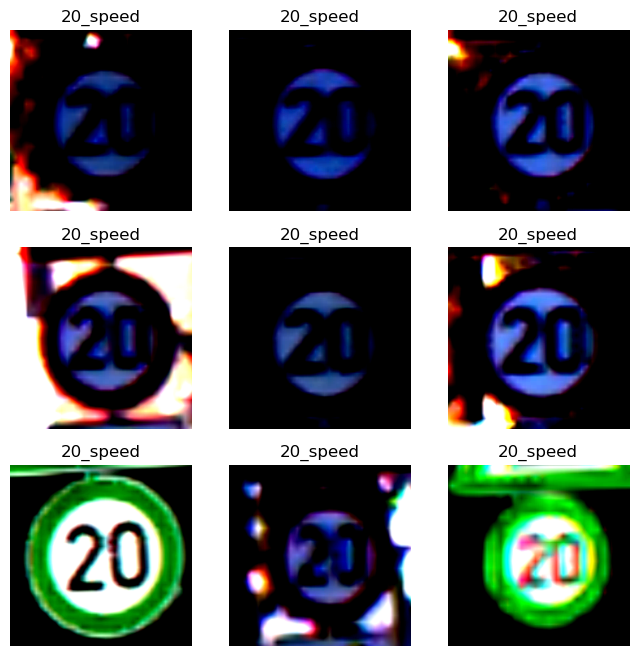

Dataset ImageFolder
    Number of datapoints: 12630
    Root location: ../classification_datasets/GTSRB/test/Images/
    StandardTransform
Transform: Compose(
               Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=None)
               CenterCrop(size=(224, 224))
               ColorJitter(brightness=[0.8745098039215686, 1.1254901960784314], contrast=None, saturation=[0.5, 1.5], hue=None)
               ToTensor()
               Normalize(mean=[0.33409829 0.31790429 0.32114835], std=[0.27565091 0.27287775 0.27361141])
           )


In [6]:
print("Clean Test Loader")
view_dataloader(dataset_.test_loader_clean)
print(dataset_.test_loader_clean.dataset)

Poison Train Loader


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


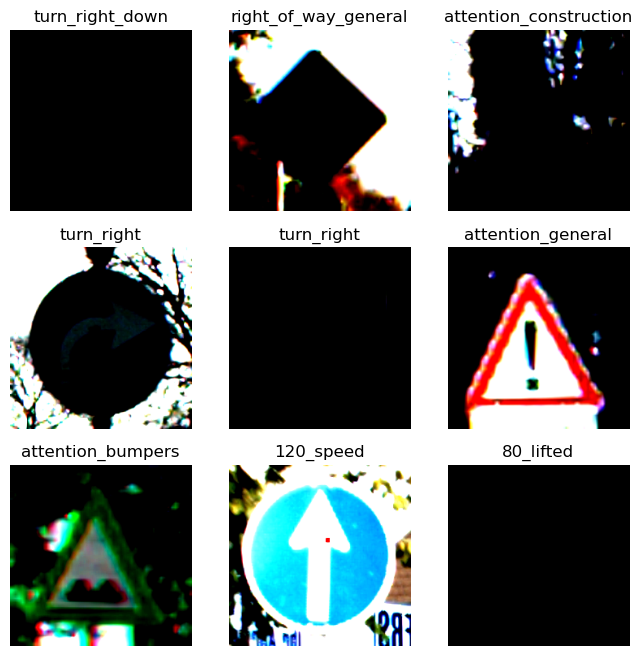

Dataset ImageFolder
    Number of datapoints: 25095
    Root location: ../classification_datasets_poisoned/GTSRB_RS/GTSRB_RS_10/train/
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=None)
               RandomHorizontalFlip(p=0.5)
               ColorJitter(brightness=[0.8745098039215686, 1.1254901960784314], contrast=None, saturation=[0.5, 1.5], hue=None)
               ToTensor()
               Normalize(mean=[0.33425963 0.31757396 0.3210416 ], std=[0.27581533 0.27270334 0.27360208])
           )

In [11]:
print("Poison Train Loader")
view_dataloader(dataset_.train_loader_poison)
dataset_.train_loader_poison.dataset

Poison Test Loader


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


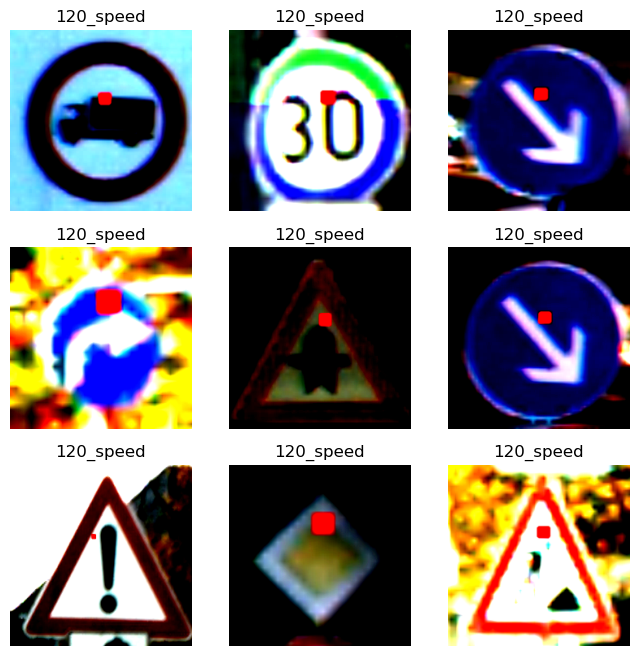

In [8]:
print("Poison Test Loader")
view_dataloader(dataset_.test_loader_poison)